In [1]:
import pandas as pd
import os
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def get_gen_number(generation_dir):
    return int(re.split('_|\\.', generation_dir.name)[1])

In [3]:
trial_dir = Path(os.path.expanduser('~/hpc-share/uvms/preliminary/charlie/trial_2'))
# Each generation_dir is the csv write-out for one generation. Includes parameters and fitness of each individual
# Ignore the final csv because it is not complete. Only includes header
generation_dirs = [trial_dir / name for name in os.listdir(trial_dir)]
# Sort according to generation number
generation_dirs.sort(key = lambda dir_ : get_gen_number(dir_))
# Load in each csv as a dataframe
dfs = [pd.read_csv(dir_) for dir_ in generation_dirs[:-1]]
all_fits =  [df['fitness'].to_list() for df in dfs]
min_fits = [np.min(fits) for fits in all_fits]
max_fits = [np.max(fits) for fits in all_fits]
avg_fits = [np.average(fits) for fits in all_fits]
std_fits = [np.std(fits) for fits in all_fits]

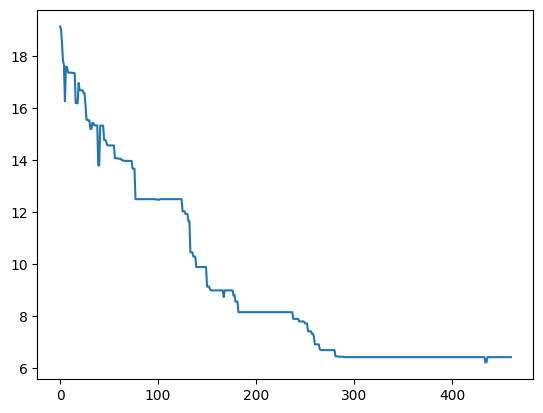

In [4]:
plt.plot(min_fits)

In [ ]:
# 500 gens is good
# I want to know how well a model generalizes once we've trained it to other trajectories
# and show a benchmark line of how well hannah's hand tuned model works

# Also curious how different